Telescope Pupil Shape: (65536,)
Masking Pupil Shape: (65536,)
Scale 1: P2V error: 3.4636787511710643 rad, 0.5512615945312379 waves, defocus distance: 6997.454194826209 microns
Scale 1: P2V error: 3.4636787511710643 rad, 0.5512615945312379 waves, defocus distance: 6997.454194826209 microns
PSF 0 shape: (512, 512), max: 34459.45244600711, min: 6.115421070065329e-14
PSF 1 shape: (512, 512), max: 16785.16326971322, min: 0.002769792061037691
PSF 2 shape: (512, 512), max: 16785.16326971322, min: 0.002769792061037691
PSF List [OldStyleField([[0.06392081, 0.09697495, 0.13354401, ..., 0.17134709,
                0.13354401, 0.09697495],
               [0.10646995, 0.14385531, 0.18178604, ..., 0.2178076 ,
                0.18178604, 0.14385531],
               [0.15416046, 0.19261081, 0.22847213, ..., 0.25936444,
                0.22847213, 0.19261081],
               ...,
               [0.2732484 , 0.36168678, 0.44606026, ..., 0.51951669,
                0.44606026, 0.36168678],
              

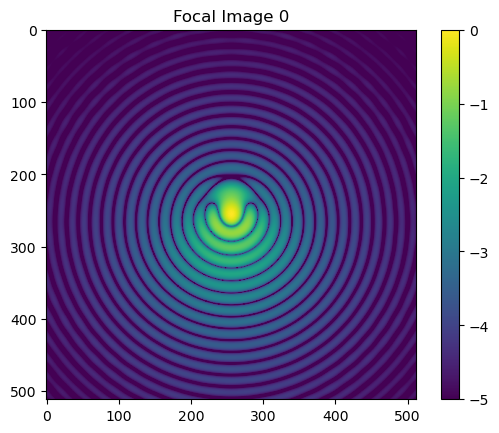

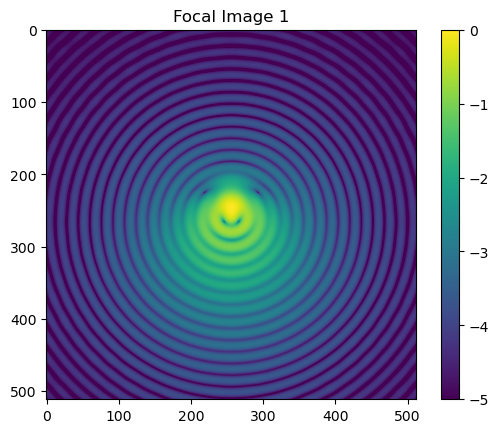

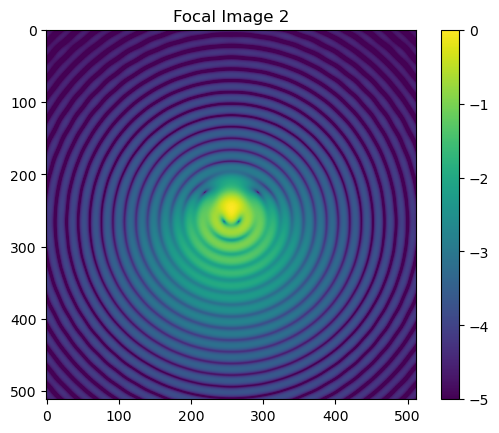

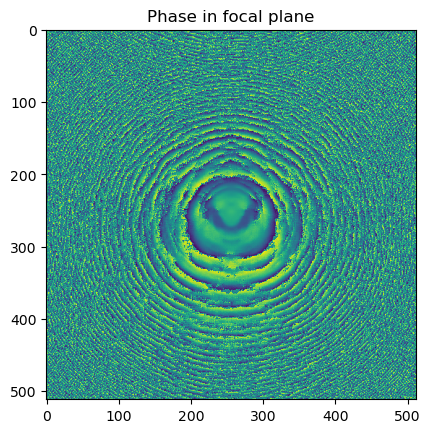

(1024, 1024)


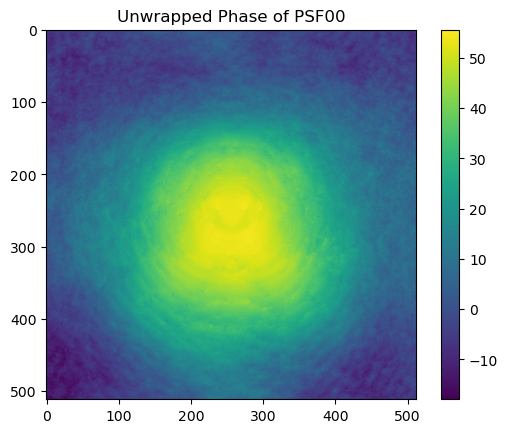

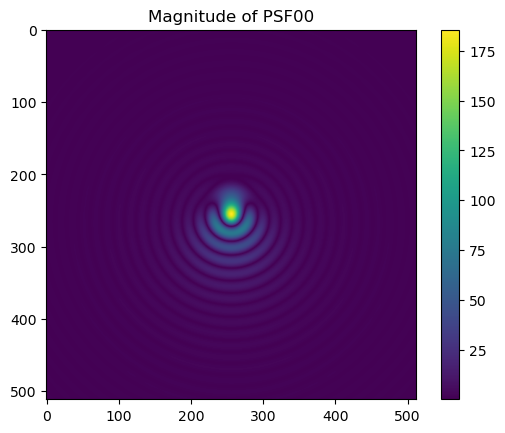

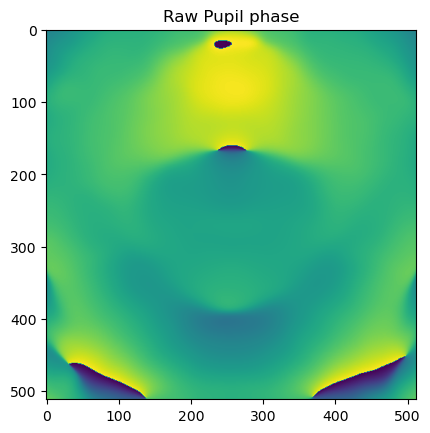

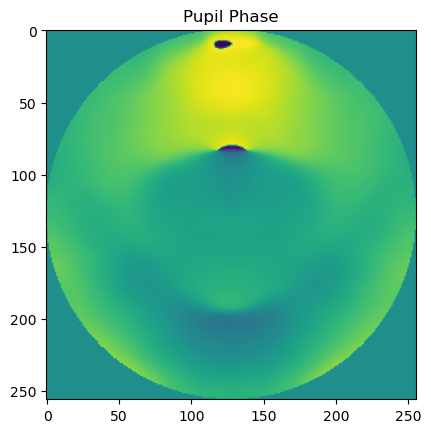

P2V error of pupil phase: 6.240343480554645
(512, 512)


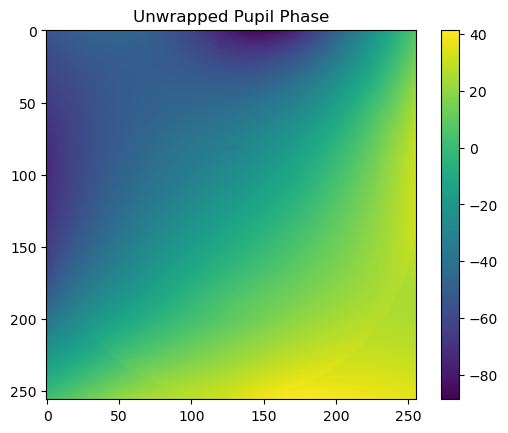

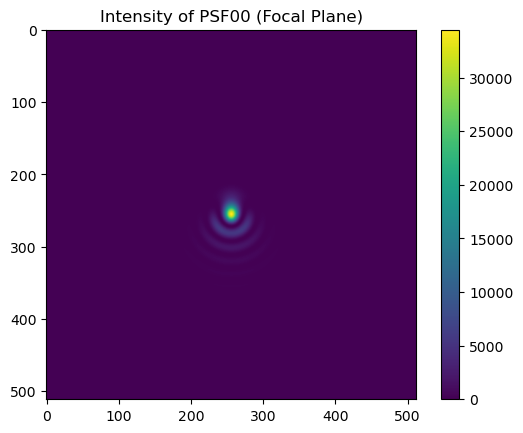

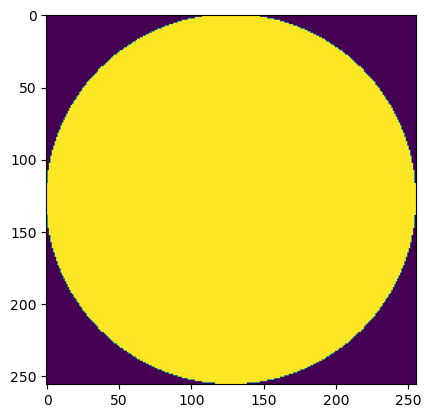

(512, 512)
P2V of Original injected error: 4.212526089508674


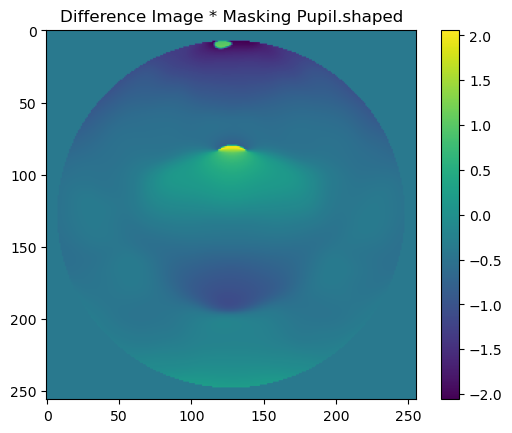

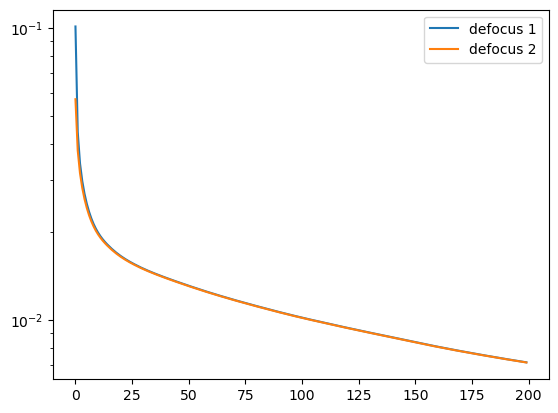

Median error in nanometers: -13.043574573484365 nm
RMS error:81.77849446230933 Nanometers
RMS error: 0.7905068228443831 radians


In [8]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
from image_sharpening import FocusDiversePhaseRetrieval, ft_rev, mft_rev, InstrumentConfiguration
from skimage.transform import resize
from skimage.restoration import unwrap_phase
from processing import phase_unwrap_2d

# Convert phase into meters using the wavelength
def phase_to_m(phase, wv):
    return phase * wv / (2 * np.pi)

# Calculate defocus distance from peak-to-valley (P2V) error in meters
def p_to_delta(P, f, D):
    return 8 * P * (f/D)**2

# Convert defocus distance into phase error
def delta_to_p(delta, f, D):
    return -1 * delta / (8 * (f/D)**2)

# Function to propagate the wavefront from pupil to focal plane and return focal intensity
def propagate_image(defocus_phase, test_ab, telescope_pupil, wavelength):
    # Set up the propagator to simulate wavefront propagation
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    # Combine the test aberration and defocus phase
    combined_phase = (test_ab + defocus_phase).ravel() 
    # Apply the phase to the telescope pupil
    pupil_field = telescope_pupil * np.exp(1j * combined_phase)
    # Create a wavefront object
    wavefront = Wavefront(pupil_field, wavelength)
    # Propagate the wavefront to the focal plane
    focal_field = prop_p2f.forward(wavefront)
    # Calculate the intensity of the focal plane image
    focal_intensity = np.abs(focal_field.electric_field.reshape(focal_grid.shape))**2
    return focal_intensity

# Function to calculate P2V error and defocus distance for a given defocus phase and scaling factor
def calculate_defocus_params(example_defocus, scale, f, D):
    defocus_phase = example_defocus * scale
    p2v_radians = np.max(defocus_phase) - np.min(defocus_phase)
    p2v_m = phase_to_m(p2v_radians, 650e-9)
    delta = p_to_delta(p2v_m, f, D)
    delta = delta if scale > 0 else -1 * delta
    return p2v_radians, delta

# Generate PSFs for different defocus scales and calculate associated defocus distances
def generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength):
    psf_list = []
    distance_list = []
    dx_list = [2.0071] * len(scales)

    # Ensure defocus and test aberration have compatible shapes
    example_defocus = example_defocus.reshape(telescope_pupil.shape)
    test_ab = test_ab.reshape(telescope_pupil.shape)

    # Calculate the PSF without defocus (reference)
    no_defocus_phase = np.zeros_like(example_defocus)
    no_defocus_image = propagate_image(no_defocus_phase, test_ab, telescope_pupil, wavelength)
    psf_list.append(no_defocus_image)

    # Loop over the scales to generate PSFs for different defocus values
    for scale in scales:
        p2v_radians, delta = calculate_defocus_params(example_defocus, scale, f, D)
        print(f'Scale {scale}: P2V error: {p2v_radians} rad, {p2v_radians/(2*np.pi)} waves, defocus distance: {delta*1e6} microns')
        defocus_image = propagate_image(example_defocus * scale, test_ab, telescope_pupil, wavelength)
        psf_list.append(defocus_image)
        distance_list.append(delta * 1e6)  # Defocus distance in microns

    return psf_list, distance_list, dx_list

# Main function to run the focus diverse phase retrieval process
#Quiet or verbose -- look up
#zap debugging
def run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale):
    # Define constants for this run
    
    pupil_size = 10.12e-3
    small_pupil_size = 9.5e-3 
    focal_length = 500e-3
    wavelength = 650e-9
    grid_size = 256
    q = 16
    num_airy = 16
    f = focal_length
    D = pupil_size
    dx_list = [2.0071] * len(scales)
    

    # Set up pupil and focal grids
    pupil_grid = make_pupil_grid(256, pupil_size)
    focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)

    # Setup telescope and masking apertures
    aperture = make_circular_aperture(pupil_size)
    telescope_pupil = aperture(pupil_grid)
    small_aperture = make_circular_aperture(small_pupil_size)
    masking_pupil = small_aperture(pupil_grid)

    # Print shapes for debugging
    print(f"Telescope Pupil Shape: {telescope_pupil.shape}")
    print(f"Masking Pupil Shape: {masking_pupil.shape}")

    # Create initial wavefront
    wavefront = Wavefront(telescope_pupil, wavelength=wavelength)
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    pupil_image = wavefront.copy()

    # Generate Zernike polynomials for test aberrations and defocus
    influence_functions = make_zernike_basis(256, pupil_size, pupil_grid)
    test_ab = test_ab_scale * influence_functions[6]
    example_defocus = influence_functions[3].shaped

    # Generate PSFs and defocus distances for different scales
    psf_list, distance_list, dx_list = generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength)
    for i, psf in enumerate(psf_list):
        print(f"PSF {i} shape: {psf.shape}, max: {np.max(psf)}, min: {np.min(psf)}")
    
    # Output the lists
    print("PSF List", psf_list)
    print("Distance List:", distance_list)
    print("DX List:", dx_list)
    defocus_images(psf_list)
    
    # Initialize the focus diverse phase retrieval process
    mp = FocusDiversePhaseRetrieval(psf_list,650e-3, dx_list, distance_list)
    for i in range(200):
        psf00 = mp.step()
        #Debugging, want a complex-valued numpy.ndarray
        #Essentially, we are checking the type and shape of {i} after every 50 to make sure there no issues
        #if i % 50 == 0:  #Something from stack overflow(not quite sure if i adapted it correctly)
            #print(f"PSF00 at iteration {i}: type={type(psf00)}, shape={psf00.shape if hasattr(psf00, 'shape') else 'N/A'}")
            #print(f"PSF00 max: {np.max(psf00)}, min: {np.min(psf00)}")
    
    
    # Configure instrument
    seal_params = {'image_dx': 2.0071, # 
               'efl': focal_length*1e3, # SEAL effective focal length, mm
               'wavelength': 0.65, # SEAL center wavelength, microns
                'pupil_size': pupil_size*1e3, # Keck entrance pupil diameter
                    }
    conf = InstrumentConfiguration(seal_params)
    
    #Plot the Phase in focal plane
    plt.imshow(np.angle(psf00))
    plt.title(f'Phase in focal plane')
    plt.show()
    
    #Unwrap the phase and Plot unwrapped phase
    unwrapped_psf00 = phase_unwrap_2d(np.angle(psf00))
    plt.imshow(unwrapped_psf00)
    plt.colorbar()
    plt.title("Unwrapped Phase of PSF00")
    plt.show()
    
    #Further Debugging
    ##Plot the magnitude of psf00
    plt.imshow(np.abs(psf00))  # Plot magnitude of complex array
    plt.colorbar()
    plt.title("Magnitude of PSF00")
    plt.show()
                                   
    #Retrieve raw pupil phase
    raw_pupil_phase = np.angle(mft_rev(psf00, conf))
    plt.imshow(raw_pupil_phase)
    plt.title(f'Raw Pupil phase')
    plt.show()
    
    #Resize and visualize the pupil phase
    pupil_phase = resize(raw_pupil_phase, (256, 256)) * telescope_pupil.shaped
    plt.imshow(pupil_phase)
    plt.title(f'Pupil Phase')
    plt.show()
    print(f'P2V error of pupil phase: {np.max(pupil_phase) - np.min(pupil_phase)}')
                             
    #Unwrap the pupil phase, thought it could be interesting
    unwrapped_pupil_phase = phase_unwrap_2d(pupil_phase)
    plt.imshow(unwrapped_pupil_phase)  # Unwrapped pupil plane phase
    plt.colorbar()
    plt.title("Unwrapped Pupil Phase")
    plt.show()

    # Plot the intensity for PSF (Focal Plane), debugging to ensure that we at least have a psf00
    intensity_psf00 = np.abs(psf00)**2
    plt.imshow(intensity_psf00)  # Intensity in focal plane
    plt.colorbar()
    plt.title("Intensity of PSF00 (Focal Plane)")
    plt.show()
    
    #Debugging to ensure we have a decent pupil
    plt.imshow(telescope_pupil.shaped)
    plt.show()
    plt.title(f'Telescope_pupil.shaped')
    
    #Comparing to Original Error
    pupil_image.electric_field = np.exp(complex(0, 1)*telescope_pupil*(test_ab))
    plt.imshow(phase_unwrap_2d(pupil_image.phase.shaped))
    plt.colorbar()
    plt.title(f'Original Error injected')
    print(f'P2V of Original injected error: {np.max(pupil_image.phase.shaped) - np.min(pupil_image.phase.shaped)}')

    # Subtract median and calculate difference image
    med_subtracted = pupil_phase - np.median(pupil_phase[np.array(masking_pupil.shaped, dtype=bool)])
    difference_image = pupil_image.phase.shaped - med_subtracted#Masking pupil
    plt.imshow(difference_image * masking_pupil.shaped)
    plt.title(f'Difference Image * Masking Pupil.shaped')
    plt.show()
    
    #Graphing the Cost Functions, make it iterative, for i in range len[mp.cost_func]
    #plt.semilogy(mp.cost_functions[0], label='defocus 1', color='cyan')
    #plt.semilogy(mp.cost_functions[1], label='defocus 2', color='grey')
    #plt.legend()
    #plt.show()
    for i in range(len(mp.cost_functions)):
        plt.semilogy(mp.cost_functions[i], label=f'defocus {i+1}')
        
    plt.legend()
    plt.show()
    

    # Calculate median error
    check_error_region = (pupil_image.phase.shaped - med_subtracted)[np.array(masking_pupil.shaped, dtype=bool)]
    nm_med = phase_to_m(np.median(check_error_region), 650e-9) * 1e9
    print(f'Median error in nanometers: {nm_med} nm')

    #If statement to shape the telescope pupil
    if telescope_pupil.ndim == 1:
        telescope_pupil = telescope_pupil.reshape(pupil_phase.shape)
    
    #Apply the boolean mask
    valid_phase_values = med_subtracted[telescope_pupil > 0]
    mean_phase = np.mean(valid_phase_values)
    #Calculate RMS error ; convert to nano
    rms_error = np.sqrt(np.mean((valid_phase_values - mean_phase) ** 2))
    rms_nm= phase_to_m(rms_error, 650e-9)*1e9
    print(f"RMS error:{rms_nm} Nanometers")
    print(f"RMS error: {rms_error} radians")

    # Return the results
    return {"pupil_phase": pupil_phase, "difference_image": difference_image, "psf_list": psf_list, "p2v_error": np.max(pupil_phase) - np.min(pupil_phase), "rms_error": rms_error, "nm_med": nm_med}

# Function to visualize defocus images
def defocus_images(psf_list):
    for i, psf in enumerate(psf_list):
        plt.figure()
        plt.imshow(np.log10(psf / psf.max()), vmin=-5)
        plt.colorbar()
        plt.title(f'Focal Image {i}')
        plt.show()

# Call the main function, assign scale 
scales = [1,1]#Keep in mind larger scales will have negative impact on the phase unwrapping
test_ab_scale = 0.75
results = run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale)




In [2]:
from processing import phase_unwrap_2d #make a copy and substirute for the unwrap_phase hcipy to test for larger scales